Data successfully generated and split!


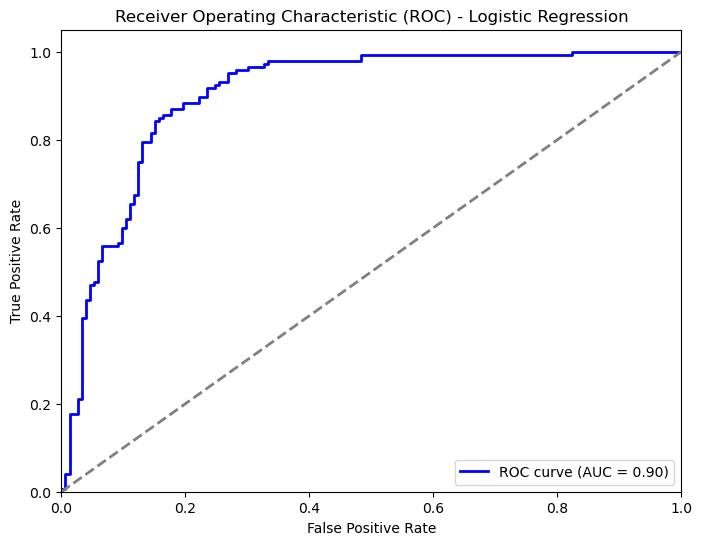

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Generate a synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_classes=2, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data successfully generated and split!")
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Get the probability scores for the positive class (class 1)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Generate a synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_classes=2, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data successfully generated and split!")
# Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Set up GridSearchCV (using 5-fold cross-validation)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, 
                              cv=5, scoring='f1', n_jobs=-1)

# Fit the grid search to the data
grid_search_rf.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search_rf.best_score_:.4f}")

Data successfully generated and split!
Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.9358


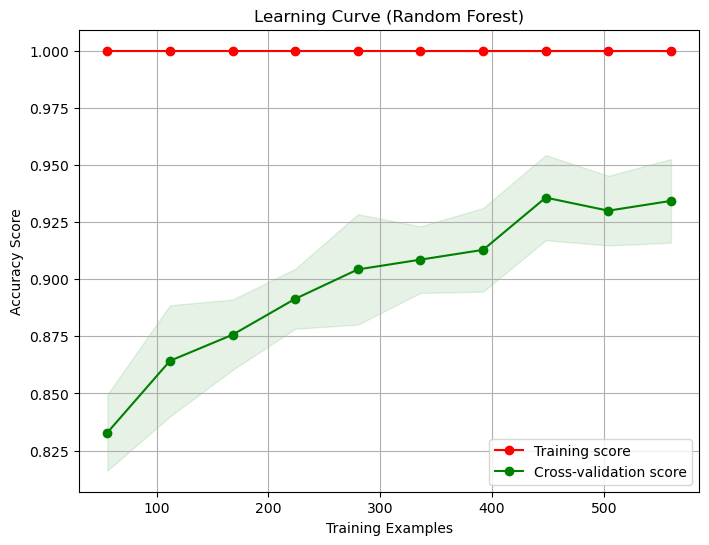

In [3]:
def plot_learning_curve(estimator, X, y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')
    
    # Calculate means and standard deviations
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.grid()
    
    # Plot the shaded areas for variance
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Plot the actual mean lines
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for the tuned Random Forest
plot_learning_curve(grid_search_rf.best_estimator_, X_train, y_train, title="Learning Curve (Random Forest)")

In [4]:
# Initialize models
models_task4 = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models_task4.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Convert to DataFrame for a clean table view
metrics_df = pd.DataFrame(results).set_index("Model")
print("\n--- Metrics Comparison Table ---")
print(metrics_df.round(4))


--- Metrics Comparison Table ---
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8333     0.7975  0.8844    0.8387
Random Forest          0.9233     0.9026  0.9456    0.9236
Decision Tree          0.7933     0.7852  0.7959    0.7905


In [5]:
# Initialize 5 different models
models_practice = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

f1_scores = []

# Train, predict, and score
for name, model in models_practice.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    
    f1_scores.append({"Model": name, "F1-Score": f1})

# Create DataFrame and rank by F1-Score in descending order
ranking_df = pd.DataFrame(f1_scores).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n--- Model Ranking by F1-Score ---")
print(ranking_df.round(4))


--- Model Ranking by F1-Score ---
                    Model  F1-Score
0     K-Nearest Neighbors    0.9467
1  Support Vector Machine    0.9435
2           Random Forest    0.9236
3     Logistic Regression    0.8387
4           Decision Tree    0.7905


In [6]:
# Define the SVM model
svm_model = SVC(random_state=42)

# Define the hyperparameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 1] 
}

# Set up GridSearchCV
grid_search_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid_svm, 
                               cv=5, scoring='f1', n_jobs=-1)

# Fit to the training data
print("\nTuning SVM... (this might take a few seconds)")
grid_search_svm.fit(X_train, y_train)

# Report results
print(f"Best SVM Parameters: {grid_search_svm.best_params_}")
print(f"Best Cross-Validation F1-Score for SVM: {grid_search_svm.best_score_:.4f}")

# Evaluate the best SVM model on the unseen test set
best_svm = grid_search_svm.best_estimator_
test_f1_svm = f1_score(y_test, best_svm.predict(X_test))
print(f"Test Set F1-Score using best SVM: {test_f1_svm:.4f}")


Tuning SVM... (this might take a few seconds)
Best SVM Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-Validation F1-Score for SVM: 0.9607
Test Set F1-Score using best SVM: 0.9533
